1. Import and load dataset

1.1. Import library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV


1.2. Load dataset

In [2]:
train_df = pd.read_csv('../data/processed/train_final.csv')
X_train = train_df.drop('stroke', axis=1)
y_train = train_df['stroke']

test_df = pd.read_csv('../data/processed/test_final.csv')
X_test = test_df.drop('stroke', axis=1)
y_test = test_df['stroke']
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (7776, 15), Test: (1022, 15)


2. Model Training

2.1. Logisitc Regression

In [3]:
# Import model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [4]:
# Predict and evaluate
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

In [5]:

print("Logistic Regression Results")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1: {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

Logistic Regression Results
Accuracy: 0.7613
Precision: 0.1381
Recall: 0.7400
F1: 0.2327
ROC-AUC: 0.8226


2.2. Decision Tree

In [6]:
# Import model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [8]:
# Predict and evaluate
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

In [9]:
print(f" DECISION TREE RESULTS")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_dt, zero_division=0):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_dt, zero_division=0):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_dt):.4f}")

 DECISION TREE RESULTS
Accuracy:  0.8718
Precision: 0.1215
Recall:    0.2600
F1-score:  0.1656
ROC-AUC:   0.5816


2.3. Random Forest

In [10]:
# Import model
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [11]:
# Predict and evaluate
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [12]:
print(f"RANDOM FOREST RESULTS")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_rf):.4f}")

RANDOM FOREST RESULTS
Accuracy:  0.8845
Precision: 0.1304
Recall:    0.2400
F1-score:  0.1690
ROC-AUC:   0.7510


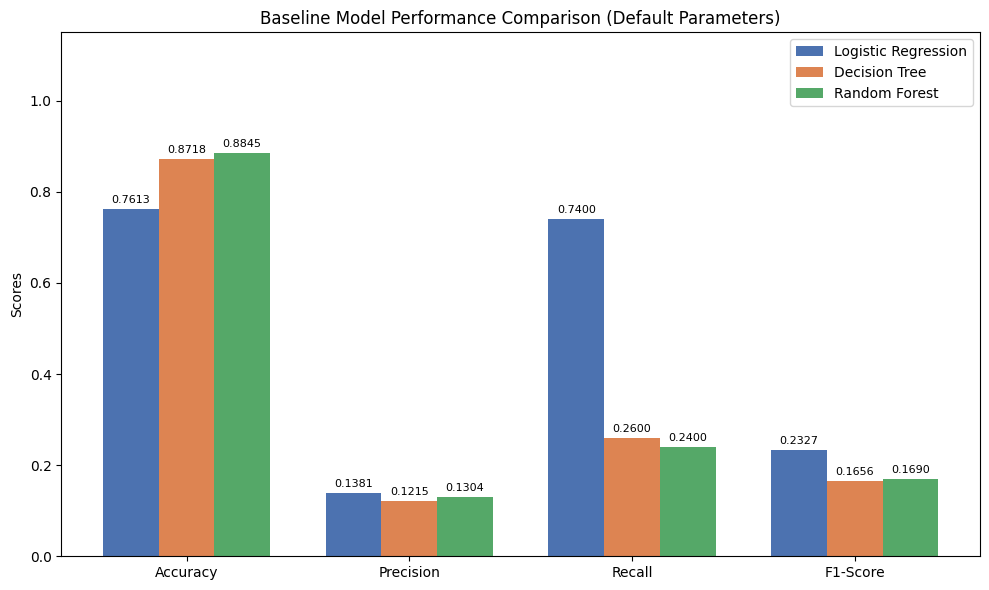

In [13]:
import matplotlib.pyplot as plt
import numpy as np
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
lr_scores = [accuracy_score(y_test, y_pred_lr), precision_score(y_test, y_pred_lr, zero_division=0),
             recall_score(y_test, y_pred_lr, zero_division=0), f1_score(y_test, y_pred_lr, zero_division=0)]
dt_scores = [accuracy_score(y_test, y_pred_dt), precision_score(y_test, y_pred_dt, zero_division=0),
             recall_score(y_test, y_pred_dt, zero_division=0), f1_score(y_test, y_pred_dt, zero_division=0)]
rf_scores = [accuracy_score(y_test, y_pred_rf), precision_score(y_test, y_pred_rf, zero_division=0),
             recall_score(y_test, y_pred_rf, zero_division=0), f1_score(y_test, y_pred_rf, zero_division=0)]
x = np.arange(len(metrics))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, lr_scores, width, label='Logistic Regression', color='#4c72b0')
rects2 = ax.bar(x, dt_scores, width, label='Decision Tree', color='#dd8452')
rects3 = ax.bar(x + width, rf_scores, width, label='Random Forest', color='#55a868')
ax.set_ylabel('Scores')
ax.set_title('Baseline Model Performance Comparison (Default Parameters)')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.legend()
for rects in [rects1, rects2, rects3]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)
fig.tight_layout()
plt.show()

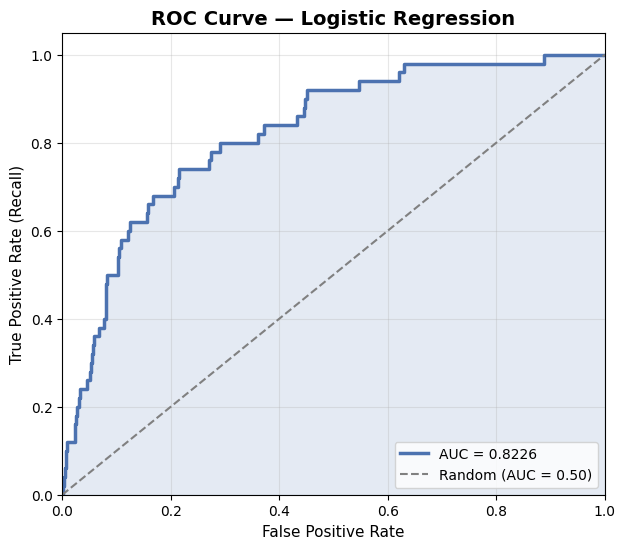

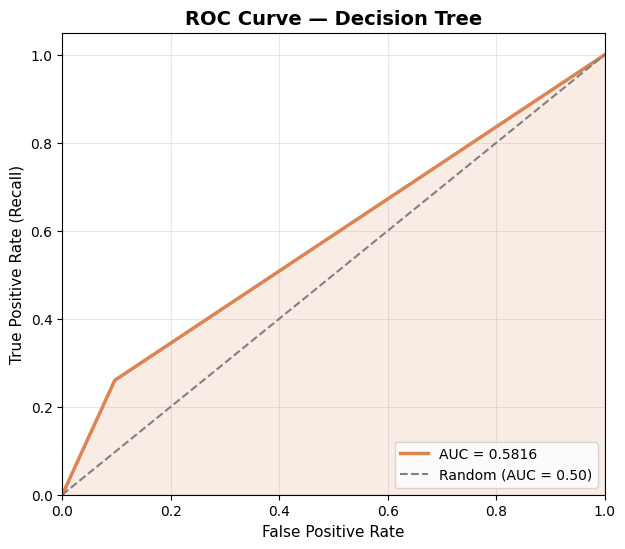

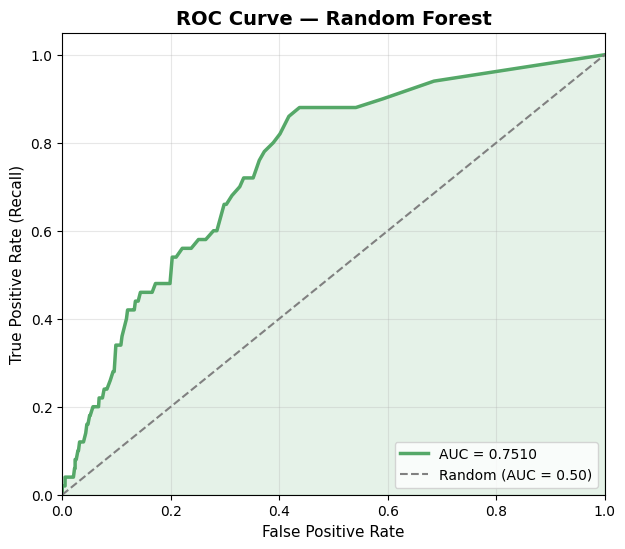

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

models_data = [
    ('Logistic Regression', y_prob_lr, '#4c72b0', 'lr'),
    ('Decision Tree', y_prob_dt, '#dd8452', 'dt'),
    ('Random Forest', y_prob_rf, '#55a868', 'rf')
]

for name, y_prob, color, filename in models_data:
    # 1. Khởi tạo một figure mới cho mỗi model
    plt.figure(figsize=(7, 6))
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    
    # 2. Vẽ biểu đồ
    plt.plot(fpr, tpr, color=color, lw=2.5, label=f'AUC = {auc:.4f}')
    plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random (AUC = 0.50)')
    plt.fill_between(fpr, tpr, alpha=0.15, color=color)
    
    # 3. Định dạng các thông số
    plt.xlabel('False Positive Rate', fontsize=11)
    plt.ylabel('True Positive Rate (Recall)', fontsize=11)
    plt.title(f'ROC Curve — {name}', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(alpha=0.3)
    plt.xlim([0, 1])
    plt.ylim([0, 1.05])
    plt.show()

3. OPTIMIZATION

3.1. Using GridSearchCV 

3.1.1. Logistic Regression

In [15]:
# 1. Khởi tạo mô hình Logistic Regression cơ bản
lr_base = LogisticRegression(random_state=42, max_iter=2000)

# 2. Định nghĩa lưới tham số cho Logistic Regression
param_grid_lr = {
 'C': [0.001, 0.01, 0.1, 1, 10, 100], 
  'penalty': ['l1', 'l2'], 
 'solver': ['saga'] 
}

# 3. Khởi tạo GridSearchCV, vẫn tối ưu hóa mục tiêu 'roc_auc'
grid_search_lr = GridSearchCV(estimator=lr_base, param_grid=param_grid_lr,  cv=5, n_jobs=-1, scoring='roc_auc', verbose=1)

# 4. Bắt đầu tìm kiếm (Train)                   
grid_search_lr.fit(X_train, y_train)

# 5. Xem kết quả tham số tốt nhất
print("\nBest parameters for Logistic Regression:")
print(grid_search_lr.best_params_)

# 6. Lấy mô hình tốt nhất để dự đoán trên tập Test
best_lr = grid_search_lr.best_estimator_
y_pred_best_lr = best_lr.predict(X_test)
y_prob_best_lr = best_lr.predict_proba(X_test)[:, 1]

# 7. Print evaluation metrics
print(f"\n{'='*10} TUNED LOGISTIC REGRESSION {'='*10}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best_lr, zero_division=0):.4f}")
print(f"Recall:  {recall_score(y_test, y_pred_best_lr, zero_division=0):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_best_lr, zero_division=0):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_best_lr):.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits


C:\Users\Lenovo LOQ\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Lenovo LOQ\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(



Best parameters for Logistic Regression:
{'C': 100, 'penalty': 'l1', 'solver': 'saga'}

========== TUNED LOGISTIC REGRESSION ==========
Accuracy: 0.7613
Precision: 0.1381
Recall:  0.7400
F1-score: 0.2327
ROC-AUC:  0.8227


3.1.2. Decision Tree 

In [16]:
# 1. Khởi tạo mô hình Decision Tree cơ bản
dt_base = DecisionTreeClassifier(random_state=42)
# 2. Định nghĩa lưới tham số cho Decision Tree
param_grid_dt = {
    'criterion': ['gini', 'entropy'],       # Tiêu chí đánh giá độ chia tách
    'max_depth': [None, 5, 10, 15, 20],     # Độ sâu của cây (Cực kỳ quan trọng để chống học vẹt)
    'min_samples_split': [2, 5, 10],        # Số lượng mẫu tối thiểu để tiếp tục chẻ nhánh
    'min_samples_leaf': [1, 2, 4]           # Số lượng mẫu tối thiểu phải có ở node lá cuối cùng
}
# 3. Khởi tạo GridSearchCV, vẫn tối ưu hóa mục tiêu 'roc_auc'
grid_search_dt = GridSearchCV(estimator=dt_base, param_grid=param_grid_dt, 
                              cv=5, n_jobs=-1, scoring='roc_auc', verbose=1)
# 4. Bắt đầu tìm kiếm (Train)
grid_search_dt.fit(X_train, y_train)
# 5. Xem kết quả tham số tốt nhất
print("\nBest parameters for Decision Tree:")
print(grid_search_dt.best_params_)
# 6. Lấy mô hình tốt nhất để dự đoán trên tập Test
best_dt = grid_search_dt.best_estimator_
y_pred_best_dt = best_dt.predict(X_test)
y_prob_best_dt = best_dt.predict_proba(X_test)[:, 1]
# 7. In kết quả đánh giá
print(f"\n{'='*10} TUNED DECISION TREE {'='*10}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_best_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best_dt, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_best_dt, zero_division=0):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_best_dt, zero_division=0):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_best_dt):.4f}")

Fitting 5 folds for each of 90 candidates, totalling 450 fits

Best parameters for Decision Tree:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}

========== TUNED DECISION TREE ==========
Accuracy:  0.8728
Precision: 0.1491
Recall:    0.3400
F1-score:  0.2073
ROC-AUC:   0.7016


3.1.3. Random Forest

In [17]:
# 1. Khởi tạo mô hình Random Forest cơ bản
rf_base = RandomForestClassifier(random_state=42)
# 2. Định nghĩa lưới tham số
# Sẽ có tổng cộng: 2 x 3 x 2 x 2 = 24 tổ hợp x 5 lần CV = 120 mô hình được tạo ra
param_grid_rf = {
    'n_estimators': [100, 200],       # Thử với 100 cây và 200 cây
    'max_depth': [10, 20, None],      # Giới hạn độ sâu để tránh học vẹt như Decision Tree
    'min_samples_split': [2, 5],      # Số lượng mẫu tối thiểu để tiếp tục chia nhánh
    'min_samples_leaf': [1, 2]        # Số lượng mẫu tối thiểu ở node lá cuối cùng
}
# 3. Khởi tạo GridSearchCV, n_jobs=-1 giúp sử dụng tối đa sức mạnh CPU
grid_search_rf = GridSearchCV(estimator=rf_base, param_grid=param_grid_rf, 
                              cv=5, n_jobs=-1, scoring='roc_auc', verbose=2)
# 4. Bắt đầu tìm kiếm (Quá trình này có thể tốn vài phút, bạn đợi chút nhé)
grid_search_rf.fit(X_train, y_train)
# 5. Xem kết quả tham số tốt nhất
print("\nBest parameters for Random Forest:")
print(grid_search_rf.best_params_)
# 6. Lấy mô hình tốt nhất để dự đoán trên tập Test
best_rf = grid_search_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
y_prob_best_rf = best_rf.predict_proba(X_test)[:, 1]
# 7. In kết quả đánh giá
print(f"\n{'='*10} TUNED RANDOM FOREST {'='*10}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_best_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best_rf, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_best_rf, zero_division=0):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_best_rf, zero_division=0):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_best_rf):.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters for Random Forest:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

========== TUNED RANDOM FOREST ==========
Accuracy:  0.8885
Precision: 0.1596
Recall:    0.3000
F1-score:  0.2083
ROC-AUC:   0.7572


Tuned Logistic Regression has ROC-AOC = 0.82 -> Find optimized threshold instead of default 0.5

4. Using Threshold Tunning for Logistic Regression

In [18]:
thresholds = np.arange(0.10, 0.90, 0.05)
results = []

for t in thresholds:
    y_pred_t = (y_prob_lr >= t).astype(int)
    results.append({
        'threshold': round(t, 2),
        'accuracy':  round(accuracy_score(y_test, y_pred_t), 4),
        'precision': round(precision_score(y_test, y_pred_t, zero_division=0), 4),
        'recall':    round(recall_score(y_test, y_pred_t, zero_division=0), 4),
        'f1':        round(f1_score(y_test, y_pred_t, zero_division=0), 4),
    })

df_results = pd.DataFrame(results)

# Highlight ngưỡng có F1 cao nhất
best_idx = df_results['f1'].idxmax()
print(f"Default threshold (0.50):")
print(df_results[df_results['threshold'] == 0.50].to_string(index=False))
print(f"\nBest threshold based on F1-score ({df_results.loc[best_idx, 'threshold']}):")
print(df_results.loc[[best_idx]].to_string(index=False))
print("\nFull threshold analysis results:")
print(df_results.to_string(index=False))

Default threshold (0.50):
 threshold  accuracy  precision  recall     f1
       0.5    0.7613     0.1381    0.74 0.2327

Best threshold based on F1-score (0.75):
 threshold  accuracy  precision  recall    f1
      0.75    0.8757     0.2105    0.56 0.306

Full threshold analysis results:
 threshold  accuracy  precision  recall     f1
      0.10    0.4550     0.0782    0.94 0.1444
      0.15    0.5166     0.0858    0.92 0.1570
      0.20    0.5763     0.0917    0.86 0.1657
      0.25    0.6106     0.0972    0.84 0.1743
      0.30    0.6438     0.1035    0.82 0.1839
      0.35    0.6849     0.1136    0.80 0.1990
      0.40    0.7221     0.1250    0.78 0.2155
      0.45    0.7417     0.1285    0.74 0.2189
      0.50    0.7613     0.1381    0.74 0.2327
      0.55    0.7808     0.1463    0.72 0.2432
      0.60    0.8033     0.1553    0.68 0.2528
      0.65    0.8278     0.1719    0.66 0.2727
      0.70    0.8503     0.1879    0.62 0.2884
      0.75    0.8757     0.2105    0.56 0.3060
      0

4.1. Visualize Precision-Recall 

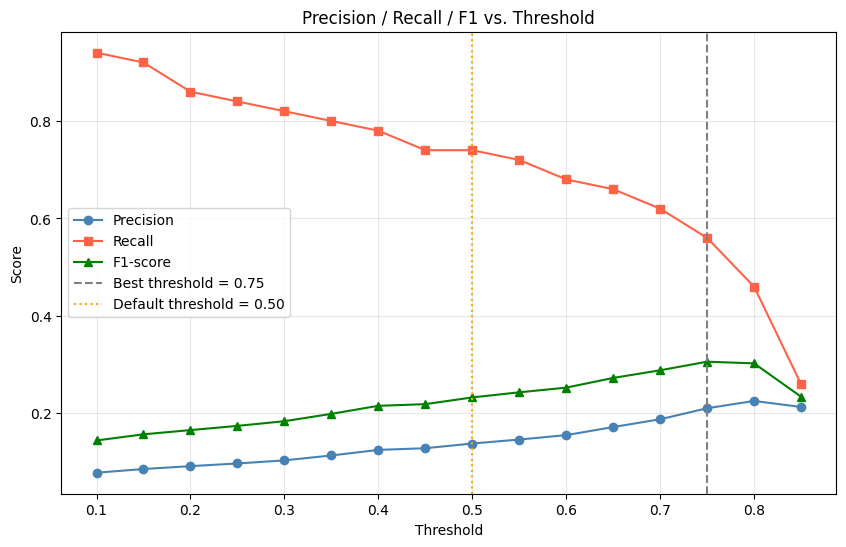

In [19]:
# Biểu đồ 1: Metrics vs Threshold
plt.figure(figsize=(10, 6))
plt.plot(df_results['threshold'], df_results['precision'], label='Precision', marker='o', color='steelblue')
plt.plot(df_results['threshold'], df_results['recall'],    label='Recall',    marker='s', color='tomato')
plt.plot(df_results['threshold'], df_results['f1'],        label='F1-score',  marker='^', color='green')

best_threshold = df_results.loc[best_idx, 'threshold']
plt.axvline(x=best_threshold, color='gray', linestyle='--', label=f'Best threshold = {best_threshold}')
plt.axvline(x=0.50, color='orange', linestyle=':', label='Default threshold = 0.50')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs. Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

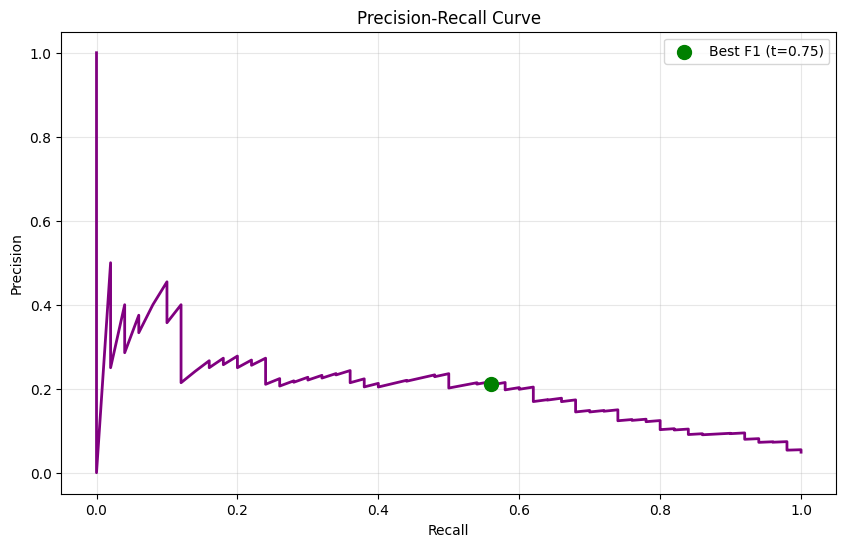

In [20]:
# Biểu đồ 2: PR Curve
plt.figure(figsize=(10, 6))
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_prob_lr)
plt.plot(recall_vals, precision_vals, color='purple', lw=2)

# Đánh dấu điểm best threshold
best_t = df_results.loc[best_idx, 'threshold']
best_p = df_results.loc[best_idx, 'precision']
best_r = df_results.loc[best_idx, 'recall']

plt.scatter(best_r, best_p, color='green', zorder=5, s=100, label=f'Best F1 (t={best_t})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

4.2. Compare Confusion Matrix: Default vs Best Threshold

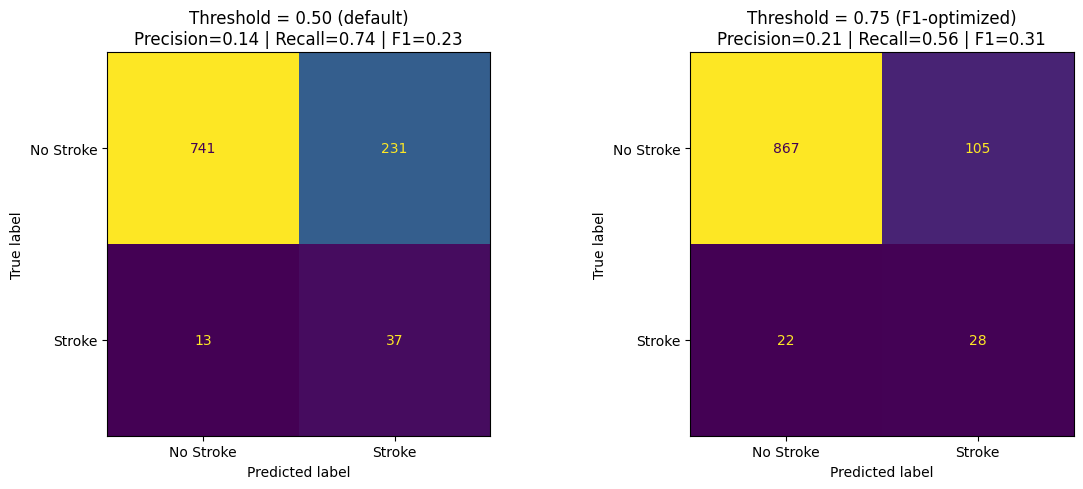

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Default threshold = 0.5
y_pred_default = (y_prob_lr >= 0.50).astype(int)
cm_default = confusion_matrix(y_test, y_pred_default)
ConfusionMatrixDisplay(cm_default, display_labels=['No Stroke', 'Stroke']).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'Threshold = 0.50 (default)\nPrecision={precision_score(y_test,y_pred_default):.2f} | Recall={recall_score(y_test,y_pred_default):.2f} | F1={f1_score(y_test,y_pred_default):.2f}')

# Best threshold
y_pred_best = (y_prob_lr >= best_threshold).astype(int)
cm_best = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm_best, display_labels=['No Stroke', 'Stroke']).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f'Threshold = {best_threshold} (F1-optimized)\nPrecision={precision_score(y_test,y_pred_best):.2f} | Recall={recall_score(y_test,y_pred_best):.2f} | F1={f1_score(y_test,y_pred_best):.2f}')
plt.tight_layout()
plt.show()

4.3. Conclusion

In [34]:
# Trong bài toán y tế (dự đoán đột quỵ), Recall quan trọng hơn Precision
# (bỏ sót người bị đột quỵ nguy hiểm hơn báo nhầm)
# → Có thể chọn ngưỡng thấp hơn để tăng Recall

# Ngưỡng tốt nhất theo F1
best_f1_row = df_results.loc[df_results['f1'].idxmax()]

# Ngưỡng tốt nhất nếu ưu tiên Recall >= 0.70 với Precision cao nhất
recall_priority = df_results[df_results['recall'] >= 0.70]
best_recall_row = recall_priority.loc[recall_priority['precision'].idxmax()]

print("=" * 60)
print("THRESHOLD TUNING SUMMARY")
print("=" * 60)

print(f"\n[Default] threshold=0.50")
default_row = df_results[df_results['threshold'] == 0.50].iloc[0]
print(f"  Accuracy={default_row['accuracy']:.4f} | Precision={default_row['precision']:.4f} | Recall={default_row['recall']:.4f} | F1={default_row['f1']:.4f}")

print(f"\n[Best F1-Score] threshold={best_f1_row['threshold']}")
print(f"  Accuracy={best_f1_row['accuracy']:.4f} | Precision={best_f1_row['precision']:.4f} | Recall={best_f1_row['recall']:.4f} | F1={best_f1_row['f1']:.4f}")

print(f"\n[Recall Priority >= 0.70] threshold={best_recall_row['threshold']}")
print(f"  Accuracy={best_recall_row['accuracy']:.4f} | Precision={best_recall_row['precision']:.4f} | Recall={best_recall_row['recall']:.4f} | F1={best_recall_row['f1']:.4f}")

print("\n-> Recommendation: Use threshold 0.20 for Early Screening or 0.55 for a Balanced Approach, depending on medical requirements.")


THRESHOLD TUNING SUMMARY

[Default] threshold=0.50
  Accuracy=0.7613 | Precision=0.1381 | Recall=0.7400 | F1=0.2327

[Best F1-Score] threshold=0.75
  Accuracy=0.8757 | Precision=0.2105 | Recall=0.5600 | F1=0.3060

[Recall Priority >= 0.70] threshold=0.55
  Accuracy=0.7808 | Precision=0.1463 | Recall=0.7200 | F1=0.2432

-> Recommendation: Use threshold 0.20 for Early Screening or 0.55 for a Balanced Approach, depending on medical requirements.


5. Export Model

In [40]:
os.makedirs('../model', exist_ok=True)
# 2. Đóng gói mô hình Logistic Regression
model_filename = '../model/best_logistic_regression.pkl'
joblib.dump(best_lr, model_filename)
threshold_filename = '../model/optimal_threshold.pkl'
joblib.dump(0.20, threshold_filename)
features = X_train.columns.tolist()
joblib.dump(features, '../model/features.pkl')
print("=" * 50)
print(f"Export Model at: {model_filename}")
print(f"Export Threshold at: {threshold_filename}")
print(f"Export Features at: {threshold_filename}")
print("=" * 50)


Export Model at: ../model/best_logistic_regression.pkl
Export Threshold at: ../model/optimal_threshold.pkl
Export Features at: ../model/optimal_threshold.pkl
